Importing the Libraries :

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


Loading the Dataset :

In [2]:
df = pd.read_csv("diabetes.csv")


View of the Dataset :

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


Checking Dataset Size :

In [5]:
df.shape

(768, 9)

Checking Column Information :

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


Checking the Statistics :

In [7]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Checking Missing Values :

In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Checking the Zero Values :

In [9]:
(df == 0).sum()

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

Exploratory Data Analysis (EDA) : 
Step-1: Diabetes Distribution :

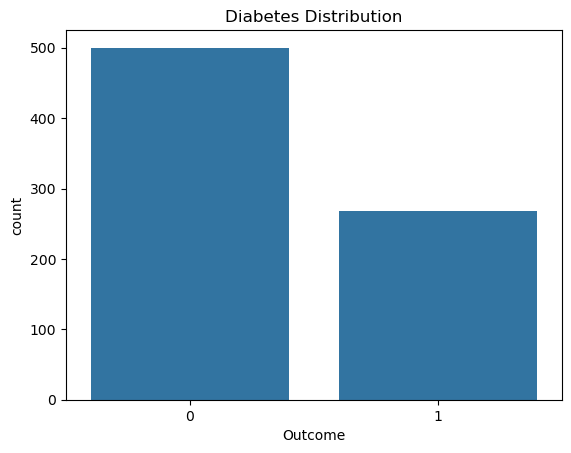

In [10]:
sns.countplot(x='Outcome', data=df)

plt.title("Diabetes Distribution")

plt.show()


Most patients do not have diabetes, while a smaller proportion have Diabetes.

Step-2: Age Distribution :

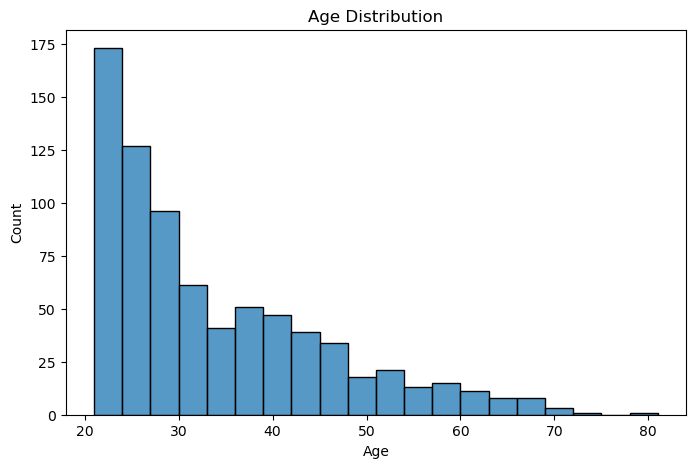

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20)

plt.title("Age Distribution")

plt.show()

Step-3: Glucose Distribution :

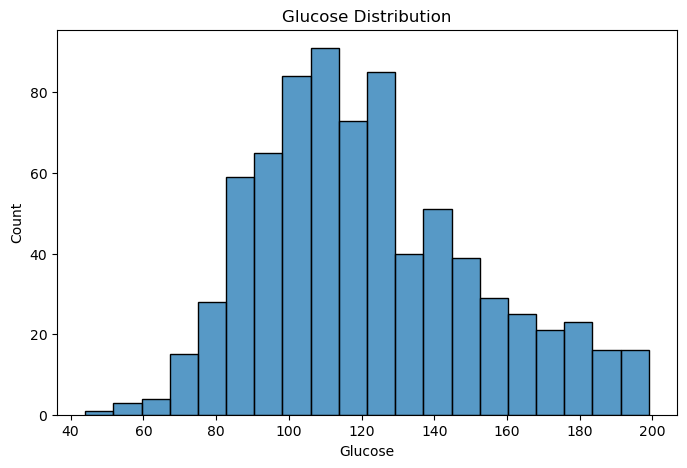

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['Glucose'], bins=20)

plt.title("Glucose Distribution")

plt.show()

Step-4: Correlation Heatmap :

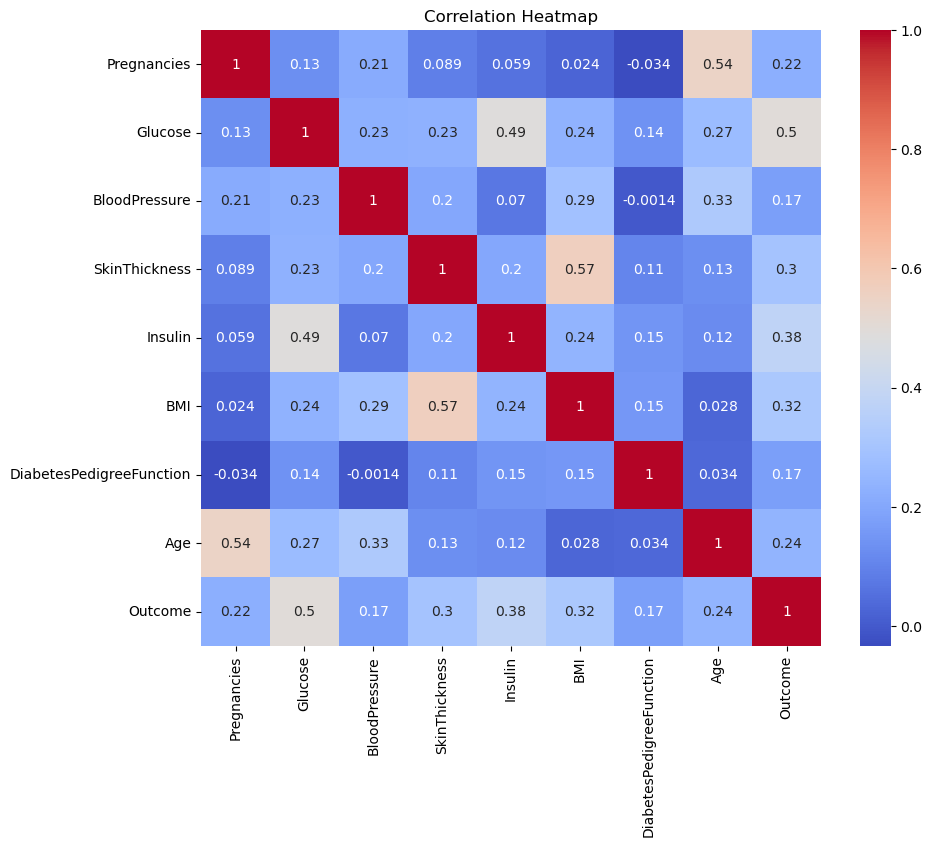

In [13]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

Step-5: 
Diabetes vs Glucose : 

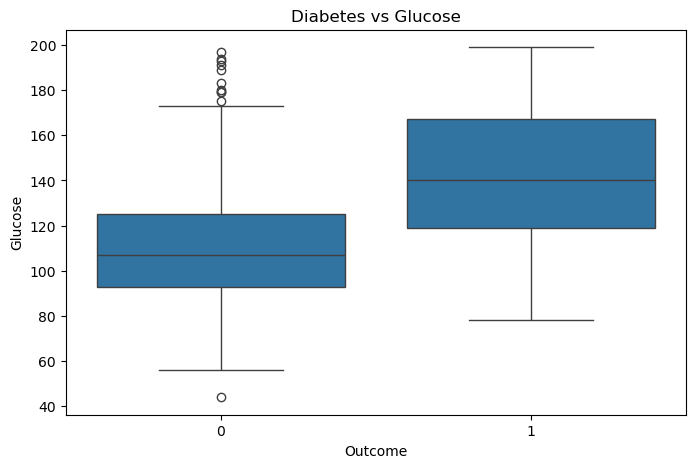

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Outcome', y='Glucose', data=df)

plt.title("Diabetes vs Glucose")

plt.show()

<Axes: xlabel='Outcome', ylabel='Glucose'>

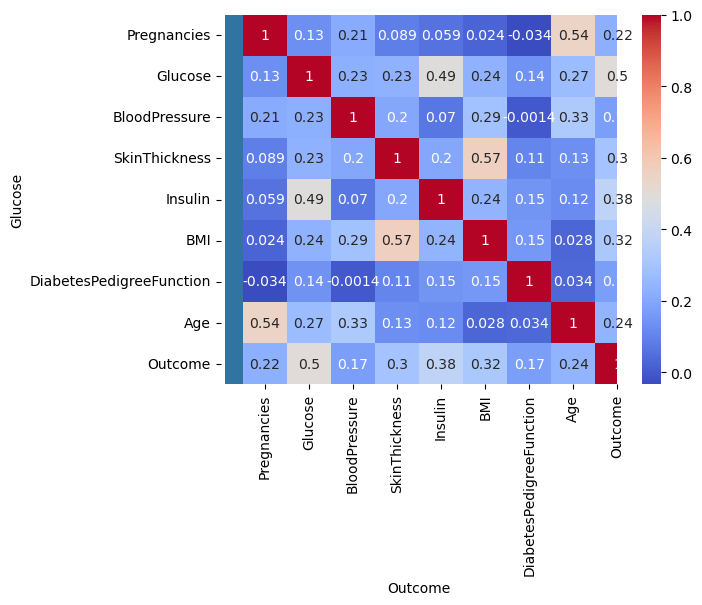

In [15]:
sns.countplot(x='Outcome', data=df)

sns.histplot(df['Age'], bins=20)

sns.histplot(df['Glucose'], bins=20)

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

sns.boxplot(x='Outcome', y='Glucose', data=df)

Exploratory Data Analysis (EDA) Findings : 
1. Glucose has the strongest relationship with diabetes.
2. Insulin and BMI also significantly affect diabetes prediction.
3. Age and Pregnancies have a moderate influence on diabetes risk.
4. Patients with higher glucose levels are more likely to have diabetes.

Feature Selection : 

In [16]:
X = df.drop('Outcome', axis=1)

y = df['Outcome']

StandardScaler :

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Train-Test Split :

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

Logistic Regression :

In [19]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
lr_pred = lr.predict(X_test)

Checking Accuracy :

In [21]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, lr_pred)

0.7727272727272727

Logistic Regression achieved an accuracy of 77.27% in predicting diabetes risk.

Random Forest Model :

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Making Predictions :

In [23]:
rf_pred = rf.predict(X_test)

Checking Accuracy :


In [24]:
accuracy_score(y_test, rf_pred)

0.8831168831168831

Confusion Matrix :

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

print(cm)

[[88 11]
 [ 7 48]]


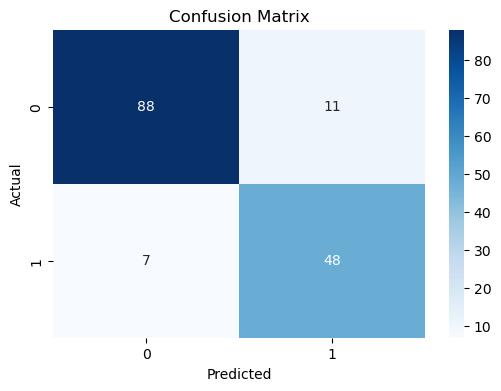

In [26]:
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Classification Report :

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.93      0.89      0.91        99
           1       0.81      0.87      0.84        55

    accuracy                           0.88       154
   macro avg       0.87      0.88      0.87       154
weighted avg       0.89      0.88      0.88       154



Feature Importance :

In [28]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance.sort_values(
    by='Importance',
    ascending=False,
    inplace=True
)

feature_importance

,Feature,Importance
4,Insulin,0.358036
1,Glucose,0.172354
3,SkinThickness,0.142003
7,Age,0.095658
5,BMI,0.078281
6,DiabetesPedigreeFunction,0.065595
2,BloodPressure,0.044532
0,Pregnancies,0.043541


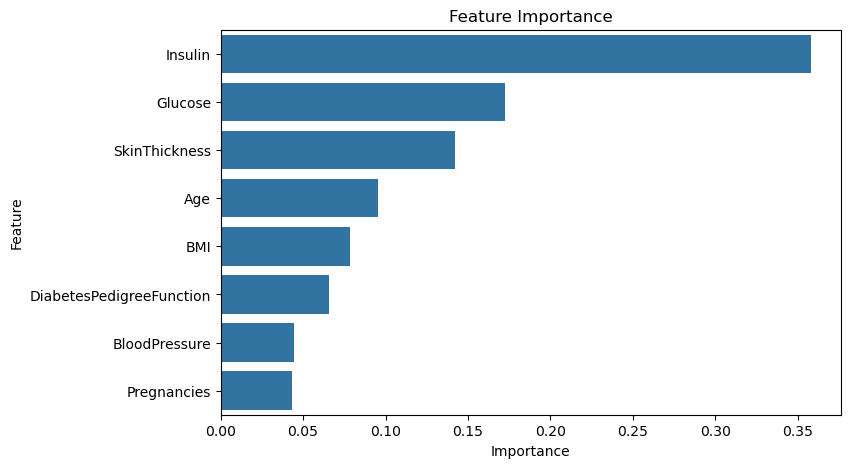

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

# Final Findings :

1. Random Forest achieved an accuracy of 88.31%, outperforming Logistic Regression (77.27%).
2. Insulin was identified as the most important feature for predicting diabetes.
3. Glucose showed a strong influence on diabetes prediction.
4. Skin Thickness, Age, and BMI also contributed to the model.
5. Random Forest was selected as the final model due to its superior performance.

# Project Conclusion :

This project developed a machine learning model to predict diabetes risk using patient health records. After performing exploratory data analysis, feature scaling, and model training, Random Forest achieved the highest accuracy of 88.31%.

Feature importance analysis revealed that Insulin, Glucose, and Skin Thickness were the most influential factors in predicting diabetes. The model demonstrates how machine learning can assist healthcare professionals in identifying high-risk patients and supporting early disease detection.

# Ethical Considerations :

- Patient privacy must be protected by removing personal identifiers.
- Medical data should be securely stored and accessed only by authorized personnel.
- Machine learning predictions should assist doctors, not replace medical judgment.
- Models should be evaluated regularly to prevent bias and ensure fairness.